Пример генерации пары сигналов с заданными параметрами и фиксированным сдвигом по фазе. С последующим определением фазового сдвига между ними и частоты релаксации

In [31]:
# Эта строчка требуется чтобы при изменении в других файлах проекта при перезапуске
# автоматически обновлялись импортируемые методы
%load_ext autoreload 
%autoreload 2

# Поиск корневой папки
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np

# Импорт логики и визуализации
import model as md
import view as vw

# Иморт названий методов поиска фазы
from model.relevant_methods import phase_methods

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# Параметры сигналов
F_main_real = 440e3 # Частота сигналов 440 кГц
phase_real = 30 # Фазовый сдвиг между сигналами 30 градусов
fs_mult = 30 # Нормированная частота дискретизации 30 отсчётов на период
duration_T = 50 # Длинна сигнала в периодах 50 периодов
gen_unstable = 1 # Нестабильность частоты генератора 1 ppf
bins=12 # Разрядность АЦП 12 бит
SNR = 20 # Отношение сигнал/шум белого шума dB, это очень высокий шум приводится для наглядности работы фильтра

# Временная сетка
duration = duration_T / F_main_real
fs = F_main_real * fs_mult
t = np.linspace(0, duration, int(duration * fs))

In [ ]:
# Задание общаей мгновенной фазы и создание сигналов по этой фазе
phase = md.generate_common_phase(
    t,
    F_main_real,
    gen_unstable,
    phase0_deg=0
)
U, I = md.generate_signals_from_phase(
    phase,
    phase_diff_deg=phase_real,
    A=1 #Амплитуда сигналов
)

In [34]:
# 3. Добавление шума
U = md.add_SNR(U, SNR)#
I = md.add_SNR(I, SNR)

# 4. Добавление квантования
U=md.adc_quantize(U,int(bins),1)
I=md.adc_quantize(I,int(bins),1)

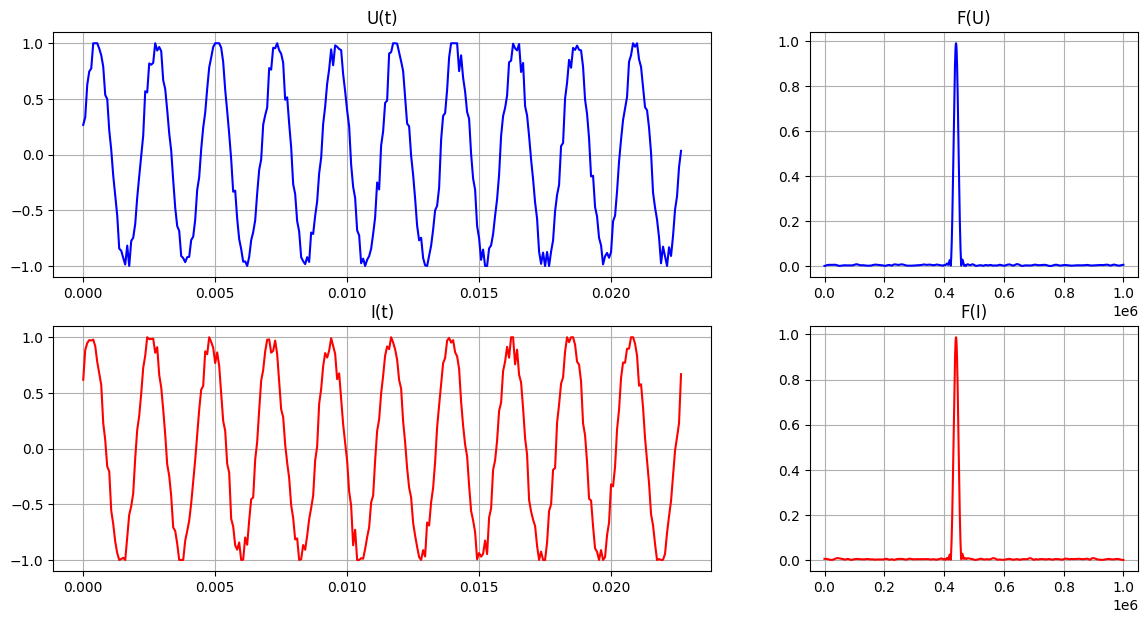

In [35]:
# Расчёт частоты сигнала и длинны периода в отсчётах
F,V = md.get_spectrum3(t,U)
F_peak_calc = F[np.argmax(V)]
T=1/F_peak_calc
T_counts=md.convert_to_counts(t,T)
window=T_counts*10 # окно для удобного вывода не всего сигнала а его части в 5

# Вывод полученных сигналов и их АЧХ
vw.show_I_U_2(t,I,U,0,window)

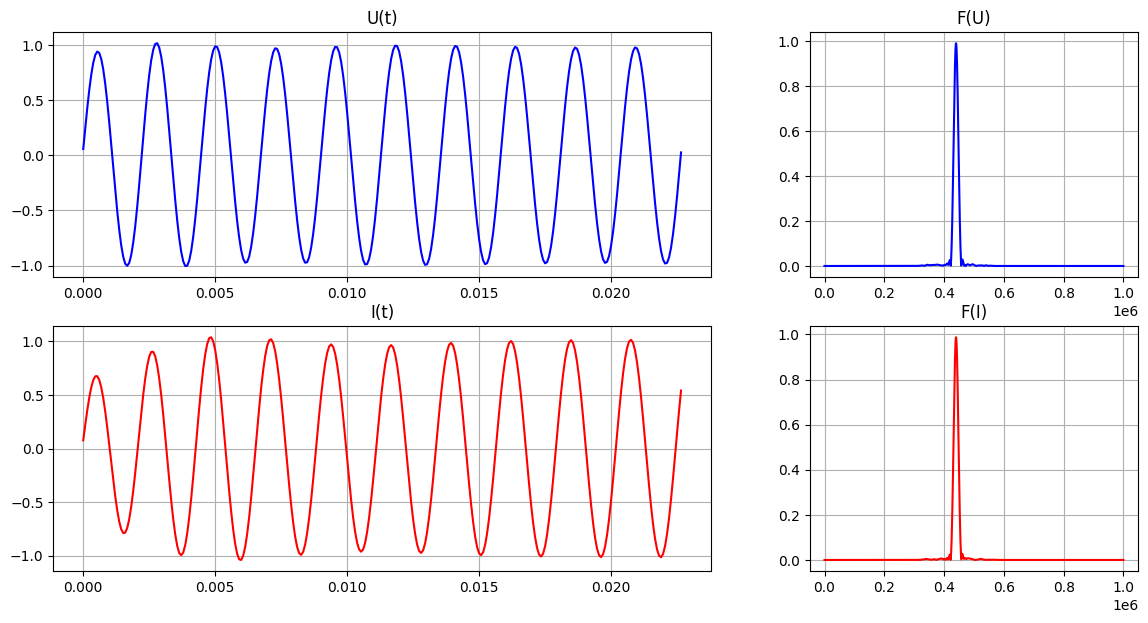

In [ ]:
# Фильтрация полосовым фильтром Баттерворта шириной 100 К порядком 5
t_f, U_f=md.filter_butter_bandpass(t,U,F_peak_calc,100e3,5)
t_f, I_f=md.filter_butter_bandpass(t,I,F_peak_calc,100e3,5)

# Вывод полученных сигналов и их АЧХ
vw.show_I_U_2(t_f,I_f, U_f,0,window)

In [37]:
# Пример расчёта фазы одним методом (FFT)
phase=md.get_phase_FFT(t_f, I_f,U_f, F_peak_calc)
print("Phase=",phase)
# Пример расчёта частоты релаксации
F_rel=md.get_F_rel(phase,F_peak_calc)
print("F_rel=",F_rel)

Phase= 29.696884745781524
F_rel= 771589.5465790454


In [38]:
# Расчёт фазы и отклонения между полученным и заданным значением различными реализованными методами
for i in range(0,len(phase_methods),1):
    phase=phase_methods[i](t_f, I_f,U_f, F_peak_calc)
    div=abs(phase_real-phase)
    print(phase_methods[i].__name__)
    print (" phase extimated=",phase," phase div=",div)

get_phase_MP
 phase extimated= 25.404738496506297  phase div= 4.5952615034937025
get_phase_ZCRR
 phase extimated= 29.706283987066627  phase div= 0.29371601293337335
get_phase_FFT
 phase extimated= 29.696884745781524  phase div= 0.3031152542184756
get_phase_HB
 phase extimated= 29.707740358909568  phase div= 0.2922596410904319
get_phase_XCOR
 phase extimated= 29.533268128211994  phase div= 0.46673187178800646
get_phase_LI
 phase extimated= 29.705686882835316  phase div= 0.294313117164684
get_phase_SWFR
 phase extimated= 29.47256482292434  phase div= 0.5274351770756596
